# Notebook 01 — SimpleMLP 784→8→4→2 on MNIST Even/Odd (digits 0,1,3,4)

**Architecture:** SimpleMLP with hidden dims [8, 4], trained on MNIST digits 0, 1, 3, 4 with even/odd binary labels.

## Structure
1. **Setup** — imports, config, device
2. **Models** — load or train 5 seeds into `data/models/`
3. **Factorization & Inspection** — BFT on seed 0: factor panels, pixel receptive fields, scaffold graphs
4. **Ablation** — 5-seed comparative sweep + causal circuit ablation
5. **New Stimuli via NNLS** — round-trip, ID train, near-OOD (excluded digits), far-OOD (synthetic)

## §0 — Imports & Config

In [ ]:
%matplotlib inline
import sys, os, pickle, copy
sys.path.insert(0, '..')

import numpy as np
import torch
import torch.nn as nn
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets
from torchvision.transforms import ToTensor
from sklearn.manifold import MDS
from sklearn.metrics.pairwise import cosine_distances

from src import (
    SimpleMLP,
    load_experiment, get_transform, get_loaders_from_config,
    collect_layer_inputs, collect_layer_inputs_generic,
    bft, evaluate,
    build_scaffold_edges, scaffold_loading_from_edges, plot_scaffold_graph,
    assign_factors_to_classes, path_from_child, extract_importance_scores,
    magnitude_scores, run_ablation_sweep, per_class_accuracy,
    select_class_circuit,
    extract_tree_nodes, extract_factor_tree_nodes,
    extract_fingerprint_matrix, compute_stimulus_similarity,
    project_stimuli_onto_tree, compute_factor_activations,
    nodes_at_layer, plot_factor_tree, top_stimuli_factor_activations,
    plot_factor_overview_panel, plot_factor_gallery, plot_input_layer_factors,
    plot_pruning_results, plot_embedding_comparison,
    compute_nmf_stability, plot_nmf_stability_figure,
    compute_k_sensitivity, plot_k_sensitivity_figure,
    save_experiment,
)
from src.training import train_epoch, label_transform_even_odd
from src.data_utils import get_mnist_loaders

matplotlib.rcParams.update({'figure.dpi': 80})
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
_nb_dir   = os.path.dirname(os.path.abspath('__file__'))
_repo_dir = os.path.dirname(_nb_dir)

MODEL_ROOT = os.path.join(_repo_dir, 'data', 'models')
CACHE_ROOT = os.path.join(_repo_dir, 'data', 'cache', 'nb01_mlp84')
FIG_DIR    = os.path.join(_repo_dir, 'figs', '01_mlp_8_4_0134')
for d in [MODEL_ROOT, CACHE_ROOT, FIG_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Experiment config ──────────────────────────────────────────────────────────
EXP_BASE      = 'mnist_even_odd_mlp_8_4_0134'
N_SEEDS       = 5
N_EPOCHS      = 30

# ── BFT config ────────────────────────────────────────────────────────────────
N_BRANCHES         = [8, 2, 2]
K_MAX_PER_LAYER    = [12, 12, 12]
STIMULUS_THRESHOLD = 0.7
N_VIZ              = 4

# ── Ablation config ───────────────────────────────────────────────────────────
N_CLASSES        = 2
CLASS_NAMES      = {0: 'even', 1: 'odd'}
ABLATION_FRACS   = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]
N_RANDOM_REPEATS = 10
PERCENTILES      = [50, 75, 90, 95, 99]
N_PER_CLASS      = 200

# ── NNLS / OOD ────────────────────────────────────────────────────────────────
TOP_N_FACTOR  = 50
IMAGE_SIDE    = 28
N_FAR_OOD     = 300

# ── Caching ───────────────────────────────────────────────────────────────────
USE_CACHED_BFT  = True
USE_CACHED_ABL  = True

print(f'MODEL_ROOT: {MODEL_ROOT}')
print(f'CACHE_ROOT: {CACHE_ROOT}')
print(f'FIG_DIR:    {FIG_DIR}')

MODEL_ROOT: /home/jb3879/Factor_Trace/data/models
CACHE_ROOT: /home/jb3879/Factor_Trace/data/cache/nb01_mlp84
FIG_DIR:    /home/jb3879/Factor_Trace/figs/01_mlp_8_4_0134


## §1 — Models: load or train 5 seeds

In [3]:
BASE_CONFIG = {
    'arch': 'SimpleMLP',
    'arch_kwargs': {'input_dim': 784, 'hidden_dims': [8, 4], 'output_dim': 2},
    'dataset': 'MNIST',
    'dataset_kwargs': {'root': '../data/', 'batch_size': 32,
                       'digit_filter': [0, 1, 3, 4]},
    'label_transform': 'even_odd',
    'analysis_layer_indices': [2, 4, 6],
    'n_per_class': 1000,
    'input_side': 28,
}

models_by_seed = {}

for seed in range(N_SEEDS):
    exp_dir = os.path.join(MODEL_ROOT, f'{EXP_BASE}_seed{seed}')
    if os.path.exists(os.path.join(exp_dir, 'weights.pt')):
        m, cfg = load_experiment(exp_dir, DEVICE)
        models_by_seed[seed] = (m, cfg)
        print(f'Seed {seed}: loaded from {exp_dir}')
    else:
        print(f'Seed {seed}: training from scratch...')
        torch.manual_seed(seed)
        np.random.seed(seed)
        m = SimpleMLP(**BASE_CONFIG['arch_kwargs']).to(DEVICE)
        cfg = dict(BASE_CONFIG, description=f'{EXP_BASE} seed {seed}')

        train_loader, test_loader = get_mnist_loaders(
            batch_size=32, root='../data/', digit_filter=[0,1,3,4])
        label_transform = label_transform_even_odd
        optimizer = torch.optim.Adam(m.parameters(), lr=1e-3)
        criterion = nn.CrossEntropyLoss()

        for ep in range(N_EPOCHS):
            train_epoch(m, train_loader, optimizer, criterion, DEVICE, label_transform)
        _, acc = evaluate(m, test_loader, criterion, DEVICE, label_transform)
        print(f'  Test acc: {acc:.4f}')

        cfg['description'] = f'{EXP_BASE} seed {seed}'
        save_experiment(m, cfg, exp_dir)
        models_by_seed[seed] = (m, cfg)
        print(f'  Saved to {exp_dir}')

# Canonical model is seed 0
model, config = models_by_seed[0]
train_loader, test_loader = get_loaders_from_config(config)
label_transform = get_transform(config['label_transform'])
_, test_acc = evaluate(model, test_loader, nn.CrossEntropyLoss(), DEVICE, label_transform)

linear_indices = model.linear_layer_indices()
LAYER_SIZES    = [model.layers[li].out_features for li in linear_indices]
print(f'\nSeed-0 test accuracy: {test_acc:.4f}')
print(f'Architecture (per-layer neurons): {LAYER_SIZES}')

Seed 0: loaded from /home/jb3879/Factor_Trace/data/models/mnist_even_odd_mlp_8_4_0134_seed0
Seed 1: loaded from /home/jb3879/Factor_Trace/data/models/mnist_even_odd_mlp_8_4_0134_seed1
Seed 2: loaded from /home/jb3879/Factor_Trace/data/models/mnist_even_odd_mlp_8_4_0134_seed2
Seed 3: loaded from /home/jb3879/Factor_Trace/data/models/mnist_even_odd_mlp_8_4_0134_seed3
Seed 4: loaded from /home/jb3879/Factor_Trace/data/models/mnist_even_odd_mlp_8_4_0134_seed4

Seed-0 test accuracy: 0.9934
Architecture (per-layer neurons): [8, 4, 2]


## §2 — Factorization & Inspection (seed 0)

### 2a — Collect layer data and run BFT

In [4]:
data = collect_layer_inputs(
    model, test_loader.dataset,
    label_transform=label_transform, n_per_class=None, device=DEVICE,
)
all_images   = data['images']        # (N, 1, 28, 28)
all_targets  = data['targets']       # (N,) even/odd labels
all_digits   = data['digits']        # (N,) original digit
layer_inputs = data['layer_inputs']  # list[(N, n_in)], forward order
n_samples    = len(all_images)
flat_imgs    = all_images.reshape(n_samples, -1)

print(f'Samples: {n_samples}')
print(f'Class distribution: {dict(zip(*np.unique(all_targets, return_counts=True)))}')
for i, li in enumerate(layer_inputs):
    print(f'  L{i+1} inputs: {li.shape}')

Samples: 4080
Class distribution: {np.int64(0): np.int64(1953), np.int64(1): np.int64(2127)}
  L1 inputs: (4080, 784)
  L2 inputs: (4080, 8)
  L3 inputs: (4080, 4)


In [5]:
_bft_cache = os.path.join(CACHE_ROOT, 'bft_seed0.pkl')

if USE_CACHED_BFT and os.path.exists(_bft_cache):
    with open(_bft_cache, 'rb') as f:
        tree_root = pickle.load(f)
    print('Loaded BFT tree from cache')
else:
    tree_root = bft(
        model, layer_inputs,
        k_max=K_MAX_PER_LAYER,
        n_branches=N_BRANCHES,
        stimulus_threshold=STIMULUS_THRESHOLD,
        weighting='img_selectivity',
        verbose=1,
        n_jobs=3,
    )
    with open(_bft_cache, 'wb') as f:
        pickle.dump(tree_root, f)
    print('BFT done, cached.')

def get_nodes_by_depth(root):
    from collections import deque
    by_depth = {}
    queue = deque([(root, 0)])
    while queue:
        node, d = queue.popleft()
        by_depth.setdefault(d, []).append(node)
        for child in node['children']:
            queue.append((child, d+1))
    return by_depth

def get_all_paths(root):
    if not root['children']: return [[root]]
    return [[root] + p for child in root['children'] for p in get_all_paths(child)]

nodes_by_depth = get_nodes_by_depth(tree_root)
all_paths      = get_all_paths(tree_root)
print(f'Tree: {len(nodes_by_depth)} depths, {sum(len(v) for v in nodes_by_depth.values())} nodes, {len(all_paths)} paths')

Loaded BFT tree from cache
Tree: 3 depths, 6 nodes, 3 paths


### 2b — Per-layer factor visualizations

In [ ]:
# ── Plot 1: Factor overview panels ────────────────────────────────────────────
# One figure per factor per node; even digits=blue, odd digits=orange
tree_nodes_all = extract_tree_nodes(tree_root)
for r in tree_nodes_all:
    path_label = 'F' + '→F'.join(str(f) for f in r['path']) if r['path'] else 'root'
    figs = plot_factor_overview_panel(
        r, all_images, all_targets, CLASS_NAMES,
        digit_targets=all_digits,
    )
    for k, fig in enumerate(figs):
        fname = f"L{r['layer_idx']+1}_{path_label.replace('→','-')}_factor{k}.pdf"
        fig.savefig(os.path.join(FIG_DIR, fname), bbox_inches='tight')
        plt.show(); plt.close(fig)

# ── Plot 4: Per-factor image gallery ──────────────────────────────────────────
# 2 rows: top-10 most active / bottom-10 least active images per factor per node
for r in tree_nodes_all:
    path_label = 'F' + '→F'.join(str(f) for f in r['path']) if r['path'] else 'root'
    for k in range(r['img_factors'].shape[1]):
        fig = plot_factor_gallery(r, all_images, all_targets, CLASS_NAMES, k=k, n=10)
        fname = f"gallery_L{r['layer_idx']+1}_{path_label.replace('→','-')}_k{k}.pdf"
        fig.savefig(os.path.join(FIG_DIR, fname), bbox_inches='tight')
        plt.show(); plt.close(fig)

### 2c — Layer-1 Pixel Receptive Fields

In [ ]:
# ── Plot 2: Input-layer pixel receptive fields ────────────────────────────────
# Shows neural_factors[:, k] for each L1 node reshaped to (n_out, 28, 28)
max_depth = max(nodes_by_depth.keys())
for r in nodes_by_depth[max_depth]:
    path_label = 'F' + '→F'.join(str(f) for f in r['path']) if r['path'] else 'root'
    figs = plot_input_layer_factors(
        r, all_images, arch='fc', image_shape=(IMAGE_SIDE, IMAGE_SIDE)
    )
    for k, fig in enumerate(figs):
        fname = f"pixel_rf_L{r['layer_idx']+1}_{path_label.replace('→','-')}_k{k}.pdf"
        fig.savefig(os.path.join(FIG_DIR, fname), bbox_inches='tight')
        plt.show(); plt.close(fig)

### 2d — Full Network Scaffold Graphs

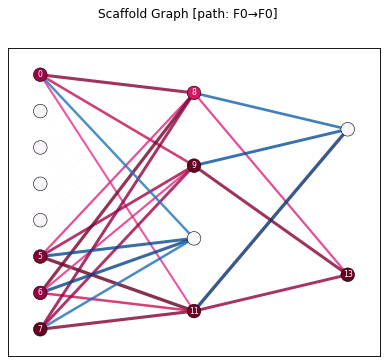

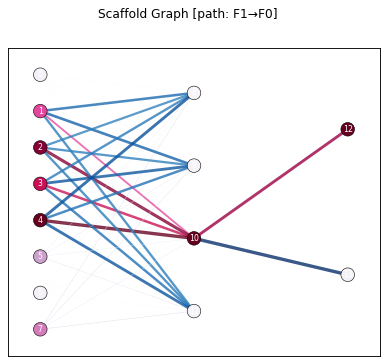

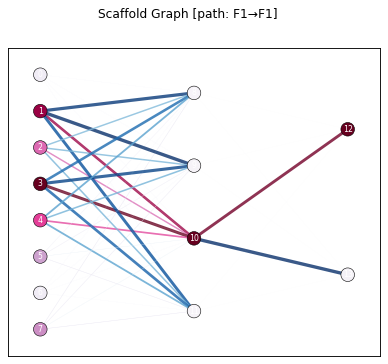

In [8]:
for path_nodes in all_paths:
    layer_results = list(reversed(path_nodes))  # L1-first order

    edge_matrices, neg_edge_matrices = build_scaffold_edges(
        layer_results[1:], fi='path', fi_seed=layer_results[0], top_pct=0.05,
    )
    loading = scaffold_loading_from_edges(edge_matrices)

    path_label = 'F' + '→F'.join(str(f) for f in path_nodes[-1]['path'])

    fig = plot_scaffold_graph(loading, edge_matrices, LAYER_SIZES,
                              neg_edge_matrices=neg_edge_matrices)
    fig.suptitle(f'Scaffold Graph [path: {path_label}]', fontsize=11)

    _pl = path_label.replace('→', '-')
    fig.savefig(os.path.join(FIG_DIR, f'scaffold_{_pl}.pdf'), bbox_inches='tight')
    plt.show()

### 2e — Robustness Analysis (Plot 5)

In [ ]:
# ── Plot 5a: NMF initialisation robustness ────────────────────────────────────
# For each BFT tree node, run NMF 10x with different seeds and compute pairwise
# cosine similarity of aligned factors.  High off-diagonal values (>0.9) indicate
# that the factorisation is stable regardless of NMF initialisation.
#
# Uses the joint_arbor matrix stored in each node.

_rob_cache = os.path.join(CACHE_ROOT, 'nmf_stability.pkl')
if USE_CACHED_BFT and os.path.exists(_rob_cache):
    with open(_rob_cache, 'rb') as f:
        stability_results = pickle.load(f)
    print('Loaded NMF stability from cache')
else:
    stability_results = {}
    for r in tree_nodes_all:
        if 'joint_arbor' not in r:
            print(f"  node {r.get('layer_name','?')}: no joint_arbor, skipping")
            continue
        X = r['joint_arbor']
        if X is None or X.shape[0] < 10:
            continue
        k = r['img_factors'].shape[1]
        key = (r['layer_idx'], str(r.get('path', [])))
        print(f"  node {r.get('layer_name','?')} k={k} X={X.shape} … ", end='', flush=True)
        sim_mat, _ = compute_nmf_stability(X, k=k, n_seeds=10)
        stability_results[key] = (sim_mat, k, r.get('layer_name', f"L{r['layer_idx']}"))
        print('done')
    with open(_rob_cache, 'wb') as f:
        pickle.dump(stability_results, f)

# Plot one stability figure per node
for key, (sim_mat, k, lname) in stability_results.items():
    fig = plot_nmf_stability_figure(sim_mat, title=f'{lname}  K={k}  NMF initialisation stability')
    fig.savefig(os.path.join(FIG_DIR, f'robustness_nmf_stability_{lname.replace("/","_")}.pdf'),
                bbox_inches='tight')
    plt.show(); plt.close(fig)

# ── Plot 5b: Model-seed robustness ────────────────────────────────────────────
# Compare BFT img_factors across 5 trained model seeds for the root node.
# Requires running BFT per seed (re-uses cached ablation BFTs from §3).
print('\nModel-seed robustness: comparing root img_factors across 5 seeds...')
from src.robustness_utils import align_factors as _align_factors

_seed_root_factors = []
for seed_idx in range(N_SEEDS):
    m_s, _ = models_by_seed[seed_idx]
    _cache_s = os.path.join(CACHE_ROOT, f'bft_seed{seed_idx}_rob.pkl')
    if USE_CACHED_BFT and os.path.exists(_cache_s):
        with open(_cache_s, 'rb') as f:
            _r = pickle.load(f)
    else:
        _ld = collect_layer_inputs(m_s, test_loader.dataset,
                                   label_transform=label_transform, n_per_class=None, device=DEVICE)
        _r = bft(m_s, _ld['layer_inputs'], k_max=K_MAX_PER_LAYER, n_branches=[1,1,N_CLASSES],
                 stimulus_threshold=STIMULUS_THRESHOLD, n_jobs=3)
        with open(_cache_s, 'wb') as f:
            pickle.dump(_r, f)
    H = _r['img_factors']          # (N, K_root)
    norms = np.linalg.norm(H, axis=0, keepdims=True)
    _seed_root_factors.append(H / (norms + 1e-12))

ref = _seed_root_factors[0]
others = _seed_root_factors[1:]
_, sim_scores = _align_factors(ref, others)
print(f'Root factor alignment across seeds: {np.array(sim_scores).mean():.3f} ± {np.array(sim_scores).std():.3f}')

# ── Plot 5c: K sensitivity ────────────────────────────────────────────────────
# Check that K* factors are also found at K*-1 and K*+1.
print('\nK sensitivity at root node...')
root_node = tree_root
if 'joint_arbor' in root_node and root_node['joint_arbor'] is not None:
    k_star = root_node['img_factors'].shape[1]
    sensitivity, _ = compute_k_sensitivity(root_node['joint_arbor'], k_star=k_star, n_seeds=5)
    fig = plot_k_sensitivity_figure(sensitivity, k_star=k_star,
                                    title=f'Root node K sensitivity (K*={k_star})')
    fig.savefig(os.path.join(FIG_DIR, 'robustness_k_sensitivity_root.pdf'), bbox_inches='tight')
    plt.show(); plt.close(fig)

## §3 — Ablation (all 5 seeds)

### 3a — Comparative ablation sweep

In [ ]:
# ── Pruning methods (Plot 6) ──────────────────────────────────────────────────
METHODS = ['bft_top', 'bft_bottom', 'magnitude', 'random']
METHOD_COLORS = {
    'bft_top':    '#e15759',
    'bft_bottom': '#f28e2b',
    'magnitude':  '#76b7b2',
    'random':     '#333333',
}
METHOD_LABELS = {
    'bft_top':    'BFT most important',
    'bft_bottom': 'BFT least important',
    'magnitude':  'Magnitude',
    'random':     'Random',
}

# BFT config for circuit tracing (single branch per class, smaller K for speed)
K_TRACE         = [12, 12, 12]
N_BRANCHES_ABL  = [1, 1, N_CLASSES]
STIM_THRESH_ABL = 0.1
N_RANDOM_REPEATS = 10

os.makedirs(os.path.join(CACHE_ROOT, 'ablation'), exist_ok=True)

In [ ]:
# Load the test set (filtered to training digits)
mnist_test_full = datasets.MNIST('../data/', train=False, download=True, transform=ToTensor())
digit_filter = config['dataset_kwargs']['digit_filter']
mask = np.isin(np.array(mnist_test_full.targets), digit_filter)
test_ds_filtered = Subset(mnist_test_full, np.where(mask)[0])
test_loader_abl  = DataLoader(test_ds_filtered, batch_size=256, shuffle=False)

all_results = []

for seed_idx in range(N_SEEDS):
    cache_path = os.path.join(CACHE_ROOT, 'ablation', f'seed{seed_idx}_v2.pkl')
    if USE_CACHED_ABL and os.path.exists(cache_path):
        print(f'[seed {seed_idx}] loading from cache')
        with open(cache_path, 'rb') as f:
            all_results.append(pickle.load(f))
        continue

    print(f'\n=== seed {seed_idx} ===')
    m_s, _ = models_by_seed[seed_idx]
    layer_data = collect_layer_inputs(
        m_s, test_ds_filtered, label_transform=label_transform_even_odd,
        n_per_class=None, device=DEVICE,
    )
    li_s  = layer_data['layer_inputs']
    tgt_s = layer_data['targets']

    # BFT with single branch per output factor (for class-circuit extraction)
    root = bft(m_s, li_s, k_max=K_TRACE, n_branches=N_BRANCHES_ABL,
               stimulus_threshold=STIM_THRESH_ABL, n_jobs=3)

    mag_sc   = magnitude_scores(m_s)
    baseline = per_class_accuracy(m_s, test_loader_abl, label_transform_even_odd, DEVICE)

    seed_results = {'baseline': baseline}
    for d in range(N_CLASSES):
        # Select the circuit most selective for class d via selectivity ratio
        bft_sc, info = select_class_circuit(root, tgt_s, d)
        if info['warning']:
            print(f'  class {d}: {info["warning"]}')
        else:
            print(f'  class {d}: k*={info["k_star"]} selectivity={info["selectivity"]:.2f}')

        score_map = {
            'bft_top':    bft_sc,
            'bft_bottom': bft_sc,
            'magnitude':  mag_sc,
            'random':     mag_sc,
        }
        seed_results[d] = {}
        for method in METHODS:
            _m = ('algo_top'    if method == 'bft_top'    else
                  'algo_bottom' if method == 'bft_bottom' else method)
            seed_results[d][method] = run_ablation_sweep(
                m_s, score_map[method], ABLATION_FRACS,
                test_loader_abl, label_transform_even_odd, DEVICE,
                method=_m, n_random_repeats=N_RANDOM_REPEATS,
            )

    with open(cache_path, 'wb') as f:
        pickle.dump(seed_results, f)
    all_results.append(seed_results)

valid = [r for r in all_results if r is not None]
print(f'\nValid seeds: {len(valid)}')

In [ ]:
# ── Plot 6: Pruning results ────────────────────────────────────────────────────
# For each class: target accuracy (left) + mean bystander accuracy (right)
# vs pruned fraction, for 4 methods, mean ± std across 5 seeds.

# Baseline accuracy at fraction 0 (unablated)
baseline_means = {d: float(np.mean([r['baseline'][d] for r in valid])) for d in range(N_CLASSES)}
baseline_stds  = {d: float(np.std( [r['baseline'][d] for r in valid])) for d in range(N_CLASSES)}

# Restructure: pruning_data[d][method][fraction] = {class_id: accuracy}
pruning_data = {d: {m: {} for m in METHODS} for d in range(N_CLASSES)}
pruning_stds = {d: {m: {} for m in METHODS} for d in range(N_CLASSES)}

for d in range(N_CLASSES):
    for method in METHODS:
        # Baseline (fraction=0): unablated accuracy
        pruning_data[d][method][0.0] = {c: baseline_means[c] for c in range(N_CLASSES)}
        pruning_stds[d][method][0.0] = {c: baseline_stds[c]  for c in range(N_CLASSES)}
        for f in ABLATION_FRACS:
            accs_by_seed = [r[d][method][f] for r in valid]  # list of {class: acc}
            pruning_data[d][method][f] = {
                c: float(np.mean([a[c] for a in accs_by_seed])) for c in range(N_CLASSES)
            }
            pruning_stds[d][method][f] = {
                c: float(np.std([a[c] for a in accs_by_seed])) for c in range(N_CLASSES)
            }

fracs_all = [0.0] + ABLATION_FRACS

figs = plot_pruning_results(
    pruning_data, CLASS_NAMES, METHODS, fracs_all,
    method_colors=METHOD_COLORS, method_labels=METHOD_LABELS,
    pruning_stds=pruning_stds,
)
for d, fig in enumerate(figs):
    fig.savefig(os.path.join(FIG_DIR, f'pruning_class{d}_{CLASS_NAMES[d]}.pdf'), bbox_inches='tight')
    plt.show(); plt.close(fig)

## §4 — New Stimuli via NNLS

### 4a — BFT factor tree for NNLS (seed 0)

In [13]:
_nnls_bft_cache = os.path.join(CACHE_ROOT, 'bft_nnls_seed0.pkl')

if USE_CACHED_BFT and os.path.exists(_nnls_bft_cache):
    with open(_nnls_bft_cache, 'rb') as f:
        nnls_root = pickle.load(f)
    print('Loaded NNLS BFT from cache')
else:
    nnls_root = bft(
        model, layer_inputs,
        k_max=[10, 1, 2], n_branches=[8, 2, 2],
        stimulus_threshold=0, weighting='img_selectivity', n_jobs=3,
    )
    with open(_nnls_bft_cache, 'wb') as f:
        pickle.dump(nnls_root, f)
    print('NNLS BFT done, cached.')

nnls_tree_nodes   = extract_tree_nodes(nnls_root)
nnls_factor_nodes = extract_factor_tree_nodes(nnls_root)

# Round-trip test
from sklearn.metrics.pairwise import paired_cosine_distances as _pcd
projected_test_rt = project_stimuli_onto_tree(nnls_root, layer_inputs)
F_orig = extract_fingerprint_matrix(nnls_root, np.arange(n_samples))
F_rt   = extract_fingerprint_matrix(projected_test_rt, np.arange(n_samples))
rt_sims = 1.0 - _pcd(F_orig, F_rt)
print(f'Round-trip cosine sim: mean={rt_sims.mean():.4f}  std={rt_sims.std():.4f}  min={rt_sims.min():.4f}')

/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


NNLS BFT done, cached.
Round-trip cosine sim: mean=0.9670  std=0.0309  min=0.8837


### 4b — Factor fingerprints & similarity (test set)

In [ ]:
F = extract_fingerprint_matrix(nnls_root, np.arange(n_samples))
print(f'Fingerprint matrix: {F.shape}')

MAX_VIZ = 300
viz_idx     = np.argsort(all_targets)[:MAX_VIZ] if n_samples > MAX_VIZ else np.argsort(all_targets)
S           = compute_stimulus_similarity(F[viz_idx])
targets_viz = all_targets[viz_idx]

# ── Similarity heatmap + intra/inter histogram ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im = axes[0].imshow(S, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
fig.colorbar(im, ax=axes[0])
for cl in np.unique(targets_viz):
    for b in np.where(np.diff((targets_viz == cl).astype(int)))[0]:
        axes[0].axhline(b + 0.5, color='k', lw=0.5)
        axes[0].axvline(b + 0.5, color='k', lw=0.5)
axes[0].set(title='Factor fingerprint similarity (sorted by class)',
            xlabel='Stimulus', ylabel='Stimulus')

S_all = compute_stimulus_similarity(F)
classes = sorted(np.unique(all_targets))
intra_vals, inter_vals = [], []
for ci, cl in enumerate(classes):
    mask  = all_targets == cl
    intra = S_all[np.ix_(mask, mask)]
    intra_vals.extend(intra[np.triu_indices_from(intra, k=1)])
    for cl2 in classes[ci + 1:]:
        inter_vals.extend(S_all[np.ix_(mask, all_targets == cl2)].ravel())
intra_arr, inter_arr = np.array(intra_vals), np.array(inter_vals)
axes[1].hist(intra_arr, bins=60, alpha=0.6, density=True,
             label=f'Intra ({intra_arr.mean():.3f})')
axes[1].hist(inter_arr, bins=60, alpha=0.6, density=True,
             label=f'Inter ({inter_arr.mean():.3f})')
axes[1].set(xlabel='Cosine similarity', ylabel='Density',
            title='Intra- vs inter-class fingerprint similarity')
axes[1].legend()

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'nnls_fingerprints.pdf'), bbox_inches='tight')
plt.show()

# ── Plot 7: Embedding comparison ───────────────────────────────────────────────
# 3 panels: MDS(fingerprints) | PCA(fingerprints) | PCA(last-layer activations)
# Panel 0→1 isolates projection-method effect; Panel 1→2 isolates representation effect.
fig = plot_embedding_comparison(
    F[viz_idx], layer_inputs[-1][viz_idx], targets_viz,
    CLASS_NAMES, digit_targets=all_digits[viz_idx],
    title='ID test-set fingerprint embeddings',
)
fig.savefig(os.path.join(FIG_DIR, 'embedding_comparison_id.pdf'), bbox_inches='tight')
plt.show(); plt.close(fig)

### 4d — Near-OOD: excluded MNIST digits (2,5,6,7,8,9)

In [ ]:
OOD_DIGITS = [d for d in range(10) if d not in digit_filter]
print(f'OOD digits: {OOD_DIGITS}')

mnist_test_full = datasets.MNIST('../data/', train=False, download=True, transform=ToTensor())
ood_labels_all  = np.array(mnist_test_full.targets)
ood_indices     = np.where(np.isin(ood_labels_all, OOD_DIGITS))[0]
ood_subset      = Subset(mnist_test_full, ood_indices)

data_ood = collect_layer_inputs_generic(
    model, ood_subset, label_transform=label_transform_even_odd,
    only_correct=False, device=DEVICE,
)
ood_images  = data_ood['images']
ood_digits  = data_ood['digits']
ood_targets = data_ood['targets']
ood_inputs  = data_ood['layer_inputs']
n_ood       = len(ood_images)
print(f'OOD samples: {n_ood}')

projected_ood    = project_stimuli_onto_tree(nnls_root, ood_inputs)
factor_nodes_ood = extract_factor_tree_nodes(projected_ood)

# ── Factor tree per OOD digit ─────────────────────────────────────────────────
unique_ood = sorted(np.unique(ood_digits))
ncols = min(3, len(unique_ood))
nrows = int(np.ceil(len(unique_ood) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows), squeeze=False)
for i, d in enumerate(unique_ood):
    ax   = axes[i // ncols][i % ncols]
    idx  = np.where(ood_digits == d)[0]
    acts = compute_factor_activations(factor_nodes_ood, idx)
    parity = 'even' if d % 2 == 0 else 'odd'
    plot_factor_tree(factor_nodes_ood, acts, ax=ax,
                     title=f'OOD digit {d} ({parity})  n={len(idx)}')
for j in range(len(unique_ood), nrows * ncols):
    axes[j // ncols][j % ncols].set_visible(False)
plt.suptitle('Near-OOD — Factor tree per excluded digit', fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'near_ood_tree_per_digit.pdf'), bbox_inches='tight')
plt.show()

# ── Plot 7: Embedding comparison — ID test vs near-OOD ────────────────────────
N_EACH = 150
rng_m  = np.random.default_rng(7)
id_sub  = rng_m.choice(n_samples, min(N_EACH, n_samples), replace=False)
ood_sub = rng_m.choice(n_ood, min(N_EACH, n_ood), replace=False)

F_id_sub  = extract_fingerprint_matrix(nnls_root, id_sub)
F_ood_sub = extract_fingerprint_matrix(projected_ood, ood_sub)
F_combo   = np.concatenate([F_id_sub, F_ood_sub])
act_combo = np.concatenate([layer_inputs[-1][id_sub], ood_inputs[-1][ood_sub]])
lbl_combo = np.concatenate([all_targets[id_sub], ood_targets[ood_sub]])
digit_combo = np.concatenate([all_digits[id_sub], ood_digits[ood_sub]])
cond_combo  = (['ID'] * len(id_sub)) + (['near-OOD'] * len(ood_sub))

fig = plot_embedding_comparison(
    F_combo, act_combo, lbl_combo,
    CLASS_NAMES, digit_targets=digit_combo,
    condition_labels=cond_combo,
    title='Near-OOD vs ID fingerprint embeddings',
)
fig.savefig(os.path.join(FIG_DIR, 'embedding_comparison_near_ood.pdf'), bbox_inches='tight')
plt.show(); plt.close(fig)

### 4e — Far OOD: synthetic images

In [ ]:
rng_f = np.random.default_rng(99)
_chk  = (np.indices((IMAGE_SIDE, IMAGE_SIDE)).sum(0) % 2).astype(np.float32)

far_ood_arrays = {
    'gaussian_noise': np.clip(
        rng_f.normal(0.5, 0.25, (N_FAR_OOD, 1, IMAGE_SIDE, IMAGE_SIDE)).astype(np.float32), 0, 1),
    'uniform_gray':   np.full((N_FAR_OOD, 1, IMAGE_SIDE, IMAGE_SIDE), 0.5, dtype=np.float32),
    'checkerboard':   np.broadcast_to(_chk, (N_FAR_OOD, 1, IMAGE_SIDE, IMAGE_SIDE)).copy().astype(np.float32),
    'inverted_test':  np.clip(1.0 - all_images[:N_FAR_OOD], 0, 1).astype(np.float32),
}

far_ood_data = {}
for name, imgs in far_ood_arrays.items():
    ds = TensorDataset(torch.from_numpy(imgs),
                       torch.zeros(len(imgs), dtype=torch.long))
    d = collect_layer_inputs_generic(
        model, ds, label_transform=label_transform_even_odd,
        only_correct=False, device=DEVICE,
    )
    d['projected_root'] = project_stimuli_onto_tree(nnls_root, d['layer_inputs'])
    d['factor_nodes']   = extract_factor_tree_nodes(d['projected_root'])
    far_ood_data[name]  = d
    print(f'{name:20s}  model acc={(d["preds"] == d["targets"]).mean():.3f}')

# ── Factor tree per far-OOD type ──────────────────────────────────────────────
n_types = len(far_ood_data)
fig, axes = plt.subplots(1, n_types, figsize=(6 * n_types, 4.5), squeeze=False)
axes = axes[0]
for ax, (name, d) in zip(axes, far_ood_data.items()):
    acts = compute_factor_activations(d['factor_nodes'], np.arange(len(d['images'])))
    plot_factor_tree(d['factor_nodes'], acts, ax=ax, title=name)
plt.suptitle('Far OOD — factor tree activation per synthetic type', y=1.02, fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'far_ood_factor_tree.pdf'), bbox_inches='tight')
plt.show()

# ── Plot 7: Embedding comparison — ID / near-OOD / far-OOD ───────────────────
N_MDS = 80
rng_m2 = np.random.default_rng(5)

F_parts, act_parts, lbl_parts, digit_parts, cond_parts = [], [], [], [], []
marker_map = {'gaussian_noise': '^', 'uniform_gray': 'D', 'checkerboard': 'P', 'inverted_test': 'X'}

# ID test
id_s2 = rng_m2.choice(n_samples, min(N_MDS, n_samples), replace=False)
F_parts.append(extract_fingerprint_matrix(nnls_root, id_s2))
act_parts.append(layer_inputs[-1][id_s2])
lbl_parts.append(all_targets[id_s2])
digit_parts.append(all_digits[id_s2])
cond_parts.extend(['ID-test'] * len(id_s2))

# Near-OOD
ood_s2 = rng_m2.choice(n_ood, min(N_MDS, n_ood), replace=False)
F_parts.append(extract_fingerprint_matrix(projected_ood, ood_s2))
act_parts.append(ood_inputs[-1][ood_s2])
lbl_parts.append(ood_targets[ood_s2])
digit_parts.append(ood_digits[ood_s2])
cond_parts.extend(['near-OOD'] * len(ood_s2))

# Far-OOD types
for name, d in far_ood_data.items():
    n  = min(N_MDS, len(d['images']))
    ss = rng_m2.choice(len(d['images']), n, replace=False)
    F_parts.append(extract_fingerprint_matrix(d['projected_root'], ss))
    act_parts.append(d['layer_inputs'][-1][ss])
    lbl_parts.append(d['targets'][ss])
    digit_parts.append(np.full(n, -1))    # no real digit label for synthetic
    cond_parts.extend([name] * n)

F_joint     = np.concatenate(F_parts)
act_joint   = np.concatenate(act_parts)
lbl_joint   = np.concatenate(lbl_parts)
digit_joint = np.concatenate(digit_parts)

# Use class labels only (no digit colouring — far-OOD digits are meaningless)
fig = plot_embedding_comparison(
    F_joint, act_joint, lbl_joint,
    CLASS_NAMES, digit_targets=None,
    condition_labels=cond_parts,
    title='ID / near-OOD / far-OOD fingerprint embeddings',
)
fig.savefig(os.path.join(FIG_DIR, 'embedding_comparison_all_ood.pdf'), bbox_inches='tight')
plt.show(); plt.close(fig)